In [8]:
import os
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def get_label_distribution_nested(labels_root_dir, data_yaml_path):
    """
    Analyzes the distribution of labels in a YOLO dataset with a nested structure.

    Args:
        labels_root_dir (str): The directory that contains all the subfolders with .txt label files.
                               e.g., 'C:/Train/training_image/' if 'bf7caa3f-d063-55dd-b583-81f883eed7ef/'
                               is directly inside it.
        data_yaml_path (str): The full path to your data.yaml file.

    Returns:
        dict: A dictionary where keys are class names and values are their counts.
    """
    if not os.path.exists(labels_root_dir):
        print(f"Error: Labels root directory not found at {labels_root_dir}")
        return None
    if not os.path.exists(data_yaml_path):
        print(f"Error: data.yaml not found at {data_yaml_path}")
        return None

    # Load class names from data.yaml
    with open(data_yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    
    class_names = data.get('names')
    if not class_names:
        print("Error: 'names' field not found in data.yaml. Cannot map class IDs to names.")
        return None

    all_class_ids = []

    # Walk through the labels_root_dir and its subdirectories
    for dirpath, dirnames, filenames in os.walk(labels_root_dir):
        # print(f"Searching in: {dirpath}") # Optional: uncomment for debugging paths
        for filename in filenames:
            if filename.endswith('.txt'):
                file_path = os.path.join(dirpath, filename)
                # print(f"Found label file: {file_path}") # Optional: uncomment for debugging found files
                with open(file_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            try:
                                class_id = int(parts[0])
                                all_class_ids.append(class_id)
                            except ValueError:
                                print(f"Warning: Invalid class_id '{parts[0]}' in {file_path}. Skipping line.")
                                continue
                            except IndexError:
                                print(f"Warning: Empty line or malformed line in {file_path}. Skipping line.")
                                continue

    # Count occurrences of each class ID
    class_id_counts = Counter(all_class_ids)

    # Map class IDs to names
    label_distribution = {}
    for class_id, count in class_id_counts.items():
        if 0 <= class_id < len(class_names):
            label_distribution[class_names[class_id]] = count
        else:
            print(f"Warning: Class ID {class_id} found in labels but not in data.yaml names. Assigning to 'Unknown_Class_{class_id}'.")
            label_distribution[f"Unknown_Class_{class_id}"] = count
            
    return label_distribution

def plot_distribution(label_distribution, title="Label Distribution in YOLO Dataset"):
    """
    Plots the label distribution as a bar chart.
    """
    if not label_distribution:
        print("No labels to plot.")
        return

    labels = list(label_distribution.keys())
    counts = list(label_distribution.values())

    # Sort by count for better visualization
    sorted_indices = np.argsort(counts)[::-1] # Descending order
    labels = [labels[i] for i in sorted_indices]
    counts = [counts[i] for i in sorted_indices]

    plt.figure(figsize=(12, 7))
    plt.bar(labels, counts, color='skyblue')
    plt.xlabel("Object Class")
    plt.ylabel("Number of Instances")
    plt.title(title)
    plt.xticks(rotation=45, ha='right') # Rotate labels for readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()



### Distribution for Training Set 1

Attempting to analyze labels in: training_set_1\labels\Train\training_image
Using data.yaml from: training_set_1\data.yaml

Label Distribution:
- Light Goods Vehicle: 3044
- Single-Unit Truck: 152
- Car: 10137
- Pedestrians: 600


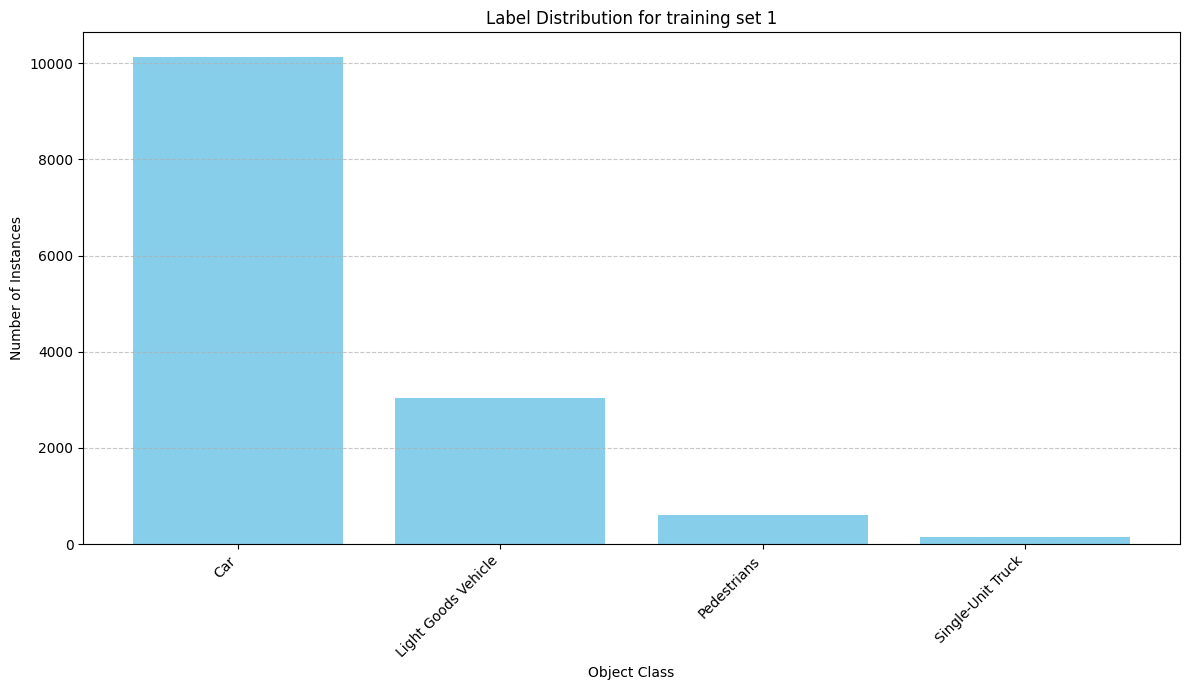

In [ ]:

# This should be the directory that *contains* folders like 'bf7caa3f-d063-55dd-b583-81f883eed7ef'
labels_root_directory = r"training_set_1\labels\Train\training_image"

# You need to locate your data.yaml file.
data_yaml_file_path = r"training_set_1\data.yaml"


print(f"Attempting to analyze labels in: {labels_root_directory}")
print(f"Using data.yaml from: {data_yaml_file_path}")

distribution = get_label_distribution_nested(labels_root_directory, data_yaml_file_path)

if distribution:
    print("\nLabel Distribution:")
    for label, count in distribution.items():
        print(f"- {label}: {count}")
    
    plot_distribution(distribution, title="Label Distribution for training set 1")
else:
    print("Could not determine label distribution.")

### Distribution for Training Set 2

Attempting to analyze labels in: training_set_2\labels\Train\training_image
Using data.yaml from: training_set_2\data.yaml

Label Distribution:
- Car: 2755
- Light Goods Vehicle: 97
- Single-Unit Truck: 84


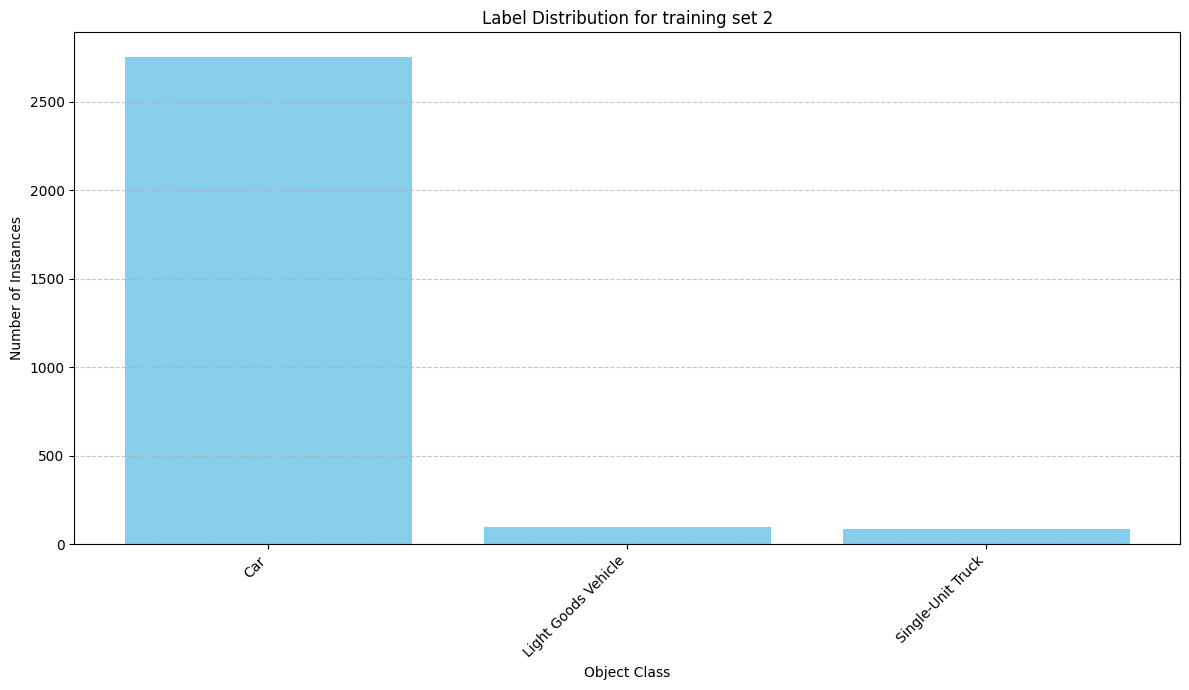

In [12]:

# This should be the directory that *contains* folders like 'bf7caa3f-d063-55dd-b583-81f883eed7ef'
# which in turn contain the .txt label files.
# Corrected path based on your input:
labels_root_directory = r"training_set_2\labels\Train\training_image"

# You need to locate your data.yaml file.
# It's typically at the top level of the CVAT download.
data_yaml_file_path = r"training_set_2\data.yaml"


print(f"Attempting to analyze labels in: {labels_root_directory}")
print(f"Using data.yaml from: {data_yaml_file_path}")

distribution = get_label_distribution_nested(labels_root_directory, data_yaml_file_path)

if distribution:
    print("\nLabel Distribution:")
    for label, count in distribution.items():
        print(f"- {label}: {count}")
    
    plot_distribution(distribution, title="Label Distribution for training set 2")
else:
    print("Could not determine label distribution.")